<a href="https://colab.research.google.com/github/fobembe/phemmyanalytics/blob/master/Copy_of_Retail_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEMAND PREDICTION WITH ELASTICITY INTEGRATIN

This notebook uses the synthetic **Normal Good** dataset and walks through:

- data loading
- full exploratory data analysis (EDA)
- age and income group creation
- manual dummy-variable creation
- multiple linear regression without a pipeline
- actual vs predicted values
- hypothetical forecasts for new clients
- individual-level and group-level price and income elasticity
- integrating elasticity measures back into the dataset

### Import the Libraries and Load the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.formula.api as smf

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/VCU/Linear Regression/cross_section_normal_good_demand.csv")
df.head()

,consumer_id,product_type,quantity_demanded,price,income,age,gender,race,occupation
0,1,Normal Good,12,13.29,63049,40,Female,White,Clerical
1,2,Normal Good,14,10.48,53457,46,Male,Black,Service
2,3,Normal Good,14,10.82,41887,40,Male,White,Professional
3,4,Normal Good,10,12.06,32677,36,Male,White,Service
4,5,Normal Good,0,17.03,29116,28,Male,White,Retired


### Conduct Basic Checks on the Data

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   consumer_id        2500 non-null   int64  
 1   product_type       2500 non-null   object 
 2   quantity_demanded  2500 non-null   int64  
 3   price              2500 non-null   float64
 4   income             2500 non-null   int64  
 5   age                2500 non-null   int64  
 6   gender             2500 non-null   object 
 7   race               2500 non-null   object 
 8   occupation         2500 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 175.9+ KB
None


In [ ]:
print("\nMissing values:")



Missing values:


In [ ]:
print(df.isna().sum())

consumer_id          0
product_type         0
quantity_demanded    0
price                0
income               0
age                  0
gender               0
race                 0
occupation           0
dtype: int64


In [ ]:
df[["quantity_demanded", "price", "income", "age"]].describe()

,quantity_demanded,price,income,age
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,12.295600,12.032068,57914.934800,44.082800
std,4.737552,2.483263,19880.187798,15.194298
min,0.000000,5.000000,12000.000000,18.000000
25%,9.000000,10.370000,44647.250000,31.000000
50%,12.000000,11.995000,57626.500000,44.000000
75%,15.000000,13.632500,70390.250000,57.000000
max,28.000000,20.520000,128520.000000,70.000000


In [ ]:
for col in ["gender", "race", "occupation"]:
    print("\n" + "="*60)
    print(col.upper())
    print(df[col].value_counts())


GENDER
gender
Female    1275
Male      1225
Name: count, dtype: int64

RACE
race
White      1077
Black       542
Mexican     447
Asian       301
Other       133
Name: count, dtype: int64

OCCUPATION
occupation
Professional     537
Service          435
Retired          371
Clerical         333
Student          333
Self-employed    260
Unemployed       231
Name: count, dtype: int64


### Categorize Age and income into groups

In [ ]:
# Age Grouping

df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

In [ ]:
print("Age group counts")
print(df["age_group"].value_counts().sort_index())

Age group counts
age_group
18-24    322
25-34    474
35-44    456
45-54    501
55-64    453
65+      294
Name: count, dtype: int64


In [ ]:
# Income Grouping

df["income_group"] = pd.cut(
    df["income"],
    bins=[0, 29999, 49999, 74999, 99999, 1000000],
    labels=["<30k", "30k-49k", "50k-74k", "75k-99k", "100k+"]
)

In [ ]:
print("\nIncome group counts")
print(df["income_group"].value_counts().sort_index())


Income group counts
income_group
<30k        213
30k-49k     640
50k-74k    1162
75k-99k     439
100k+        46
Name: count, dtype: int64


### Full Exploratory Data Analysis

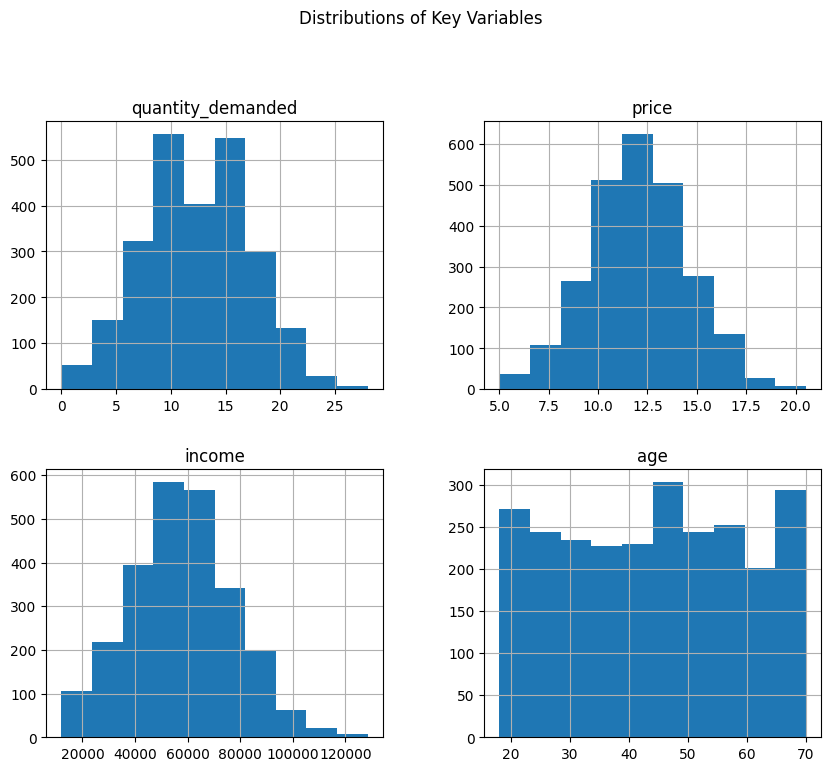

In [ ]:
df[["quantity_demanded", "price", "income", "age"]].hist(figsize=(10, 8))
plt.suptitle("Distributions of Key Variables", y=1.02)
plt.show()

#### Relationship between Price and Quantity demanded

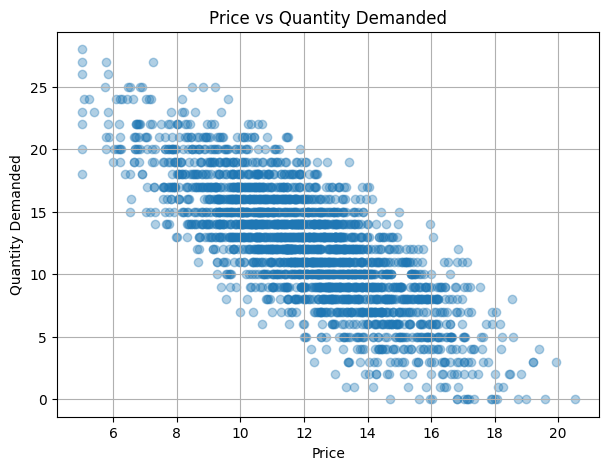

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df["price"], df["quantity_demanded"], alpha=0.35)
plt.xlabel("Price")
plt.ylabel("Quantity Demanded")
plt.title("Price vs Quantity Demanded")
plt.grid(True)
plt.show()

#### Relationship between Income and Quantity Demanded

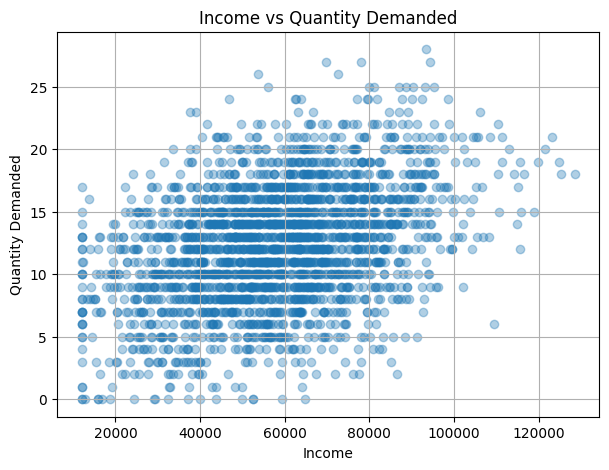

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df["income"], df["quantity_demanded"], alpha=0.35)
plt.xlabel("Income")
plt.ylabel("Quantity Demanded")
plt.title("Income vs Quantity Demanded")
plt.grid(True)
plt.show()

#### Relationship between Age and Quantity Demanded

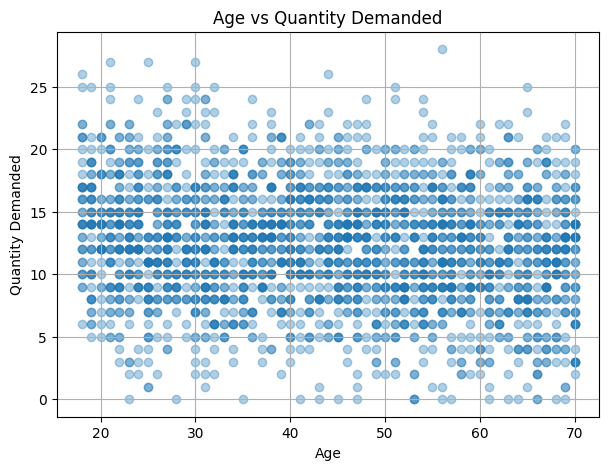

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df["age"], df["quantity_demanded"], alpha=0.35)
plt.xlabel("Age")
plt.ylabel("Quantity Demanded")
plt.title("Age vs Quantity Demanded")
plt.grid(True)
plt.show()

#### Produce the Colleration Matrix

                   quantity_demanded     price    income       age
quantity_demanded           1.000000 -0.783803  0.392642 -0.147838
price                      -0.783803  1.000000  0.004067  0.000441
income                      0.392642  0.004067  1.000000 -0.000574
age                        -0.147838  0.000441 -0.000574  1.000000


Text(0.5, 1.0, 'Correlation Matrix')

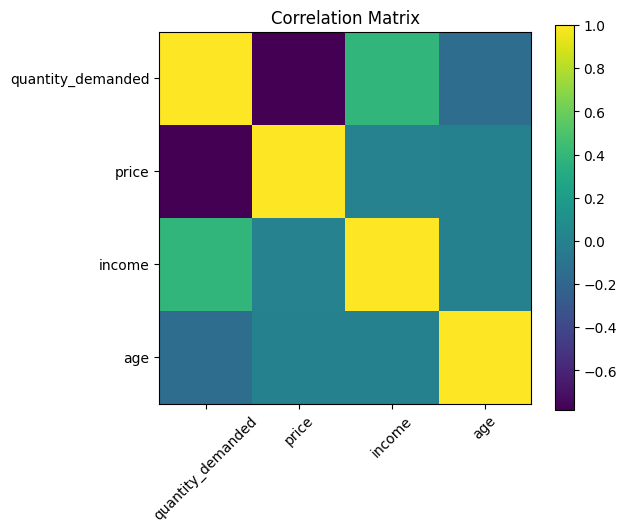

In [ ]:
corr = df[["quantity_demanded", "price", "income", "age"]].corr()
print(corr)

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")

#### Examine the Average Quantity Demand by Categorical Variables

In [ ]:
# Gender Category

print("Average quantity demanded by gender")
print(df.groupby("gender")["quantity_demanded"].mean())

Average quantity demanded by gender
gender
Female    12.778039
Male      11.793469
Name: quantity_demanded, dtype: float64


In [ ]:
# Race Category

print("\nAverage quantity demanded by race")
print(df.groupby("race")["quantity_demanded"].mean().sort_values())


Average quantity demanded by race
race
Asian      11.601329
White      12.145775
Other      12.541353
Black      12.542435
Mexican    12.751678
Name: quantity_demanded, dtype: float64


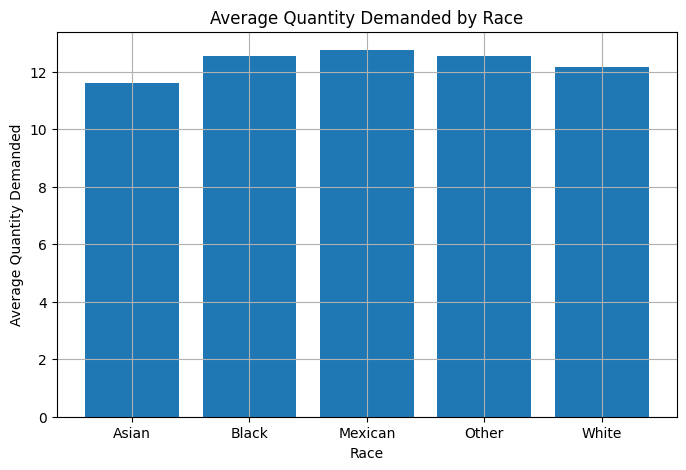

In [ ]:
plt.figure(figsize=(8, 5))
race_summary = df.groupby("race", observed=False)["quantity_demanded"].mean()
plt.bar(race_summary.index.astype(str), race_summary.values)
plt.xlabel("Race")
plt.ylabel("Average Quantity Demanded")
plt.title("Average Quantity Demanded by Race")
plt.grid(True)
plt.show();

In [ ]:
print("\nAverage quantity demanded by occupation")
print(df.groupby("occupation")["quantity_demanded"].mean().sort_values())


Average quantity demanded by occupation
occupation
Unemployed       10.809524
Retired          11.652291
Clerical         11.873874
Self-employed    12.238462
Service          12.356322
Student          13.000000
Professional     13.182495
Name: quantity_demanded, dtype: float64


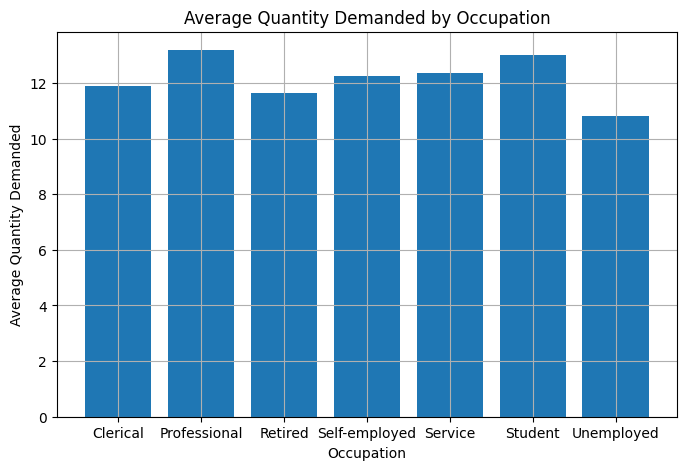

In [ ]:
plt.figure(figsize=(8, 5))
Occupation_summary = df.groupby("occupation", observed=False)["quantity_demanded"].mean()
plt.bar(Occupation_summary.index.astype(str), Occupation_summary.values)
plt.xlabel("Occupation")
plt.ylabel("Average Quantity Demanded")
plt.title("Average Quantity Demanded by Occupation")
plt.grid(True)
plt.show();

In [ ]:
print("Average quantity demanded by age group")
print(df.groupby("age_group", observed=False)["quantity_demanded"].mean())

Average quantity demanded by age group
age_group
18-24    13.639752
25-34    12.584388
35-44    12.664474
45-54    12.089820
55-64    11.644592
65+      11.139456
Name: quantity_demanded, dtype: float64


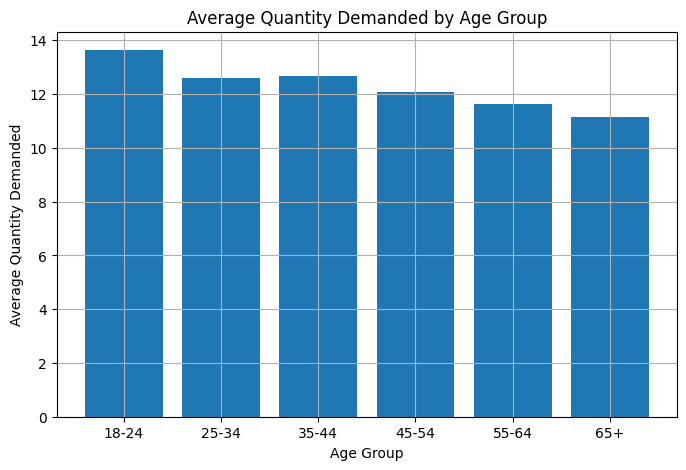

In [ ]:
plt.figure(figsize=(8, 5))
age_summary = df.groupby("age_group", observed=False)["quantity_demanded"].mean()
plt.bar(age_summary.index.astype(str), age_summary.values)
plt.xlabel("Age Group")
plt.ylabel("Average Quantity Demanded")
plt.title("Average Quantity Demanded by Age Group")
plt.grid(True)
plt.show()

In [ ]:
print("\nAverage quantity demanded by income group")
print(df.groupby("income_group", observed=False)["quantity_demanded"].mean())


Average quantity demanded by income group
income_group
<30k        8.807512
30k-49k    11.004687
50k-74k    12.494836
75k-99k    14.856492
100k+      16.934783
Name: quantity_demanded, dtype: float64


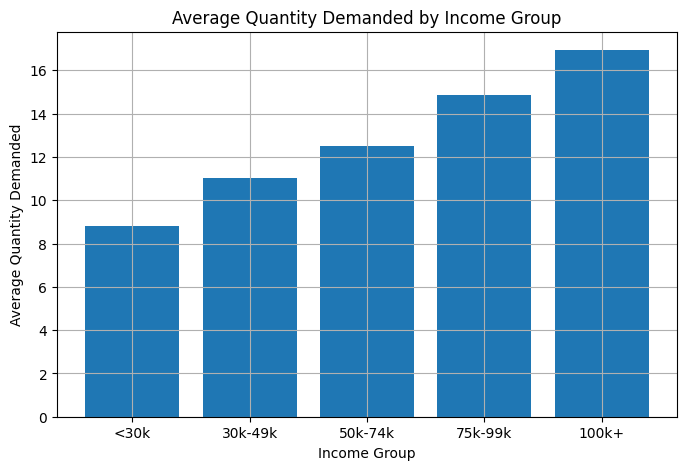

In [ ]:
plt.figure(figsize=(8, 5))
income_summary = df.groupby("income_group", observed=False)["quantity_demanded"].mean()
plt.bar(income_summary.index.astype(str), income_summary.values)
plt.xlabel("Income Group")
plt.ylabel("Average Quantity Demanded")
plt.title("Average Quantity Demanded by Income Group")
plt.grid(True)
plt.show()

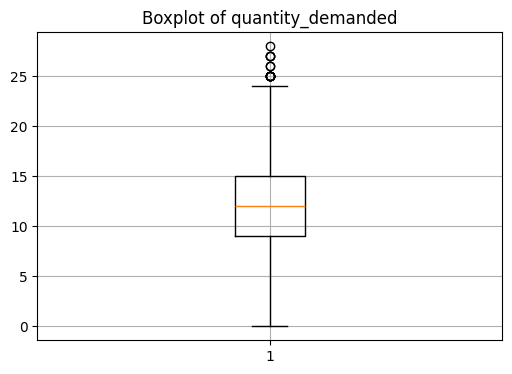

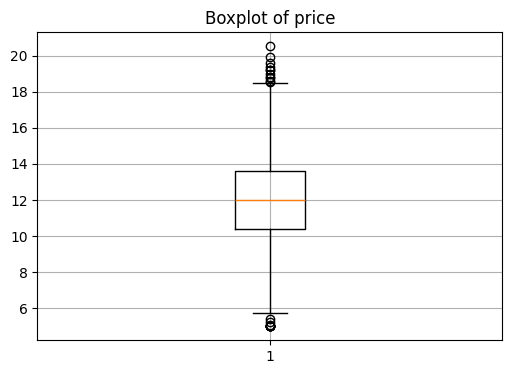

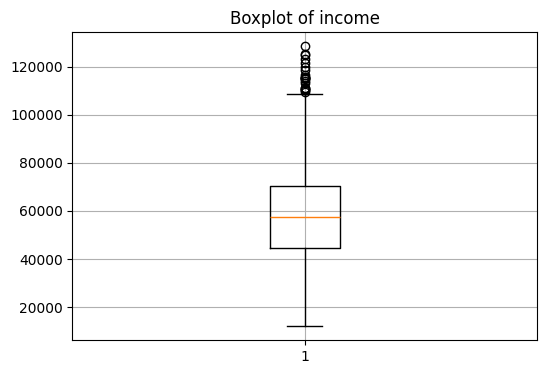

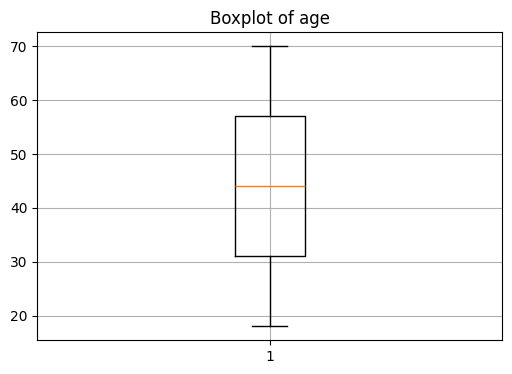

In [ ]:
for col in ["quantity_demanded", "price", "income", "age"]:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.grid(True)
    plt.show()

### Create Dummy variables for the categorical variables to perform estimation

In [ ]:
df_model = pd.get_dummies(
    df,
    columns=["gender", "race", "occupation"],
    drop_first=True
)

In [ ]:
df_model.head()

,consumer_id,product_type,quantity_demanded,price,income,age,age_group,income_group,gender_Male,race_Black,race_Mexican,race_Other,race_White,occupation_Professional,occupation_Retired,occupation_Self-employed,occupation_Service,occupation_Student,occupation_Unemployed
0,1,Normal Good,12,13.29,63049,40,35-44,50k-74k,False,False,False,False,True,False,False,False,False,False,False
1,2,Normal Good,14,10.48,53457,46,45-54,50k-74k,True,True,False,False,False,False,False,False,True,False,False
2,3,Normal Good,14,10.82,41887,40,35-44,30k-49k,True,False,False,False,True,True,False,False,False,False,False
3,4,Normal Good,10,12.06,32677,36,35-44,30k-49k,True,False,False,False,True,False,False,False,True,False,False
4,5,Normal Good,0,17.03,29116,28,25-34,<30k,True,False,False,False,True,False,True,False,False,False,False


In [ ]:
#  Define X and y

y = df_model["quantity_demanded"]

X = df_model.drop(columns=["consumer_id", "product_type", "quantity_demanded", "age_group", "income_group"])

print("X shape:", X.shape)
X.head()

X shape: (2500, 14)


,price,income,age,gender_Male,race_Black,race_Mexican,race_Other,race_White,occupation_Professional,occupation_Retired,occupation_Self-employed,occupation_Service,occupation_Student,occupation_Unemployed
0,13.29,63049,40,False,False,False,False,True,False,False,False,False,False,False
1,10.48,53457,46,True,True,False,False,False,False,False,False,True,False,False
2,10.82,41887,40,True,False,False,False,True,True,False,False,False,False,False
3,12.06,32677,36,True,False,False,False,True,False,False,False,True,False,False
4,17.03,29116,28,True,False,False,False,True,False,True,False,False,False,False


### Perform Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 2000
Testing rows: 500


### Fit the Regression Model

In [ ]:
# creat the model

model = LinearRegression()
model.fit(X_train, y_train)

# predict on the test set

y_pred = model.predict(X_test)


# print the results

print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R-squared: 0.8034717548256415
RMSE: 2.083631918674541


### Show all the coeffients

In [ ]:
coef_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient")

print("Intercept:", model.intercept_)
coef_table

Intercept: 26.851083774181646


,Variable,Coefficient
0,price,-1.506274
13,occupation_Unemployed,-1.104407
3,gender_Male,-0.888434
9,occupation_Retired,-0.348159
2,age,-0.047848
1,income,0.000093
11,occupation_Service,0.198443
6,race_Other,0.326449
10,occupation_Self-employed,0.409394
7,race_White,0.435681


### Collect the main coeffients

In [ ]:
main_coefs = coef_table[coef_table["Variable"].isin(["price", "income", "age"])]
main_coefs

,Variable,Coefficient
0,price,-1.506274
2,age,-0.047848
1,income,0.000093


### Create a table for actual and predicted

In [ ]:
results_table = X_test.copy()
results_table["Actual"] = y_test
results_table["Predicted"] = y_pred
results_table["Residual"] = results_table["Actual"] - results_table["Predicted"]
results_table["Abs_Error"] = results_table["Residual"].abs()

results_table.head(20)

,price,income,age,gender_Male,race_Black,race_Mexican,race_Other,race_White,occupation_Professional,occupation_Retired,occupation_Self-employed,occupation_Service,occupation_Student,occupation_Unemployed,Actual,Predicted,Residual,Abs_Error
1447,16.62,47906,37,False,False,False,False,True,False,False,False,False,False,True,5,3.845635,1.154365,1.154365
1114,10.58,43382,22,False,False,True,False,False,False,False,False,False,True,False,17,15.619769,1.380231,1.380231
1064,12.98,84846,24,False,True,False,False,False,False,False,False,False,False,True,16,13.846442,2.153558,2.153558
2287,10.42,65602,40,False,False,False,False,True,False,False,False,False,True,False,18,16.757254,1.242746,1.242746
1537,13.11,40374,39,True,True,False,False,False,False,True,False,False,False,False,7,8.653051,-1.653051,1.653051
668,9.71,43444,58,False,False,True,False,False,True,False,False,False,False,False,17,14.894345,2.105655,2.105655
1583,12.63,80304,49,True,False,True,False,False,False,False,True,False,False,False,14,13.243035,0.756965,0.756965
2404,9.88,48950,47,True,False,False,False,True,True,False,False,False,False,False,14,14.475099,-0.475099,0.475099
497,12.65,63728,61,True,False,False,False,True,False,False,False,False,False,True,7,9.264384,-2.264384,2.264384
2480,15.86,62272,33,True,False,False,False,True,False,False,True,False,False,False,5,7.147003,-2.147003,2.147003


In [ ]:
# sort by absolute error

results_table.sort_values("Abs_Error", ascending=False).head(20)

,price,income,age,gender_Male,race_Black,race_Mexican,race_Other,race_White,occupation_Professional,occupation_Retired,occupation_Self-employed,occupation_Service,occupation_Student,occupation_Unemployed,Actual,Predicted,Residual,Abs_Error
1708,10.50,79372,48,False,False,True,False,False,True,False,False,False,False,False,11,17.533683,-6.533683,6.533683
1503,9.57,53404,54,False,False,True,False,False,False,False,False,False,False,False,10,15.583213,-5.583213,5.583213
1258,9.99,37467,51,True,False,False,False,True,False,True,False,False,False,False,7,12.056580,-5.056580,5.056580
1123,14.41,60838,27,True,False,True,False,False,False,True,False,False,False,False,4,9.041486,-5.041486,5.041486
1797,9.61,79384,29,False,False,False,False,False,True,False,False,False,False,False,24,19.034231,4.965769,4.965769
810,16.05,74127,50,False,False,False,False,True,False,False,True,False,False,False,13,8.041477,4.958523,4.958523
430,12.96,38065,63,True,False,False,False,True,True,False,False,False,False,False,13,8.055017,4.944983,4.944983
2293,11.87,54760,59,False,True,False,False,False,False,False,False,False,True,False,18,13.103611,4.896389,4.896389
929,16.42,77907,61,False,False,True,False,False,True,False,False,False,False,False,3,7.857881,-4.857881,4.857881
2349,16.52,65245,67,False,False,True,False,False,True,False,False,False,False,False,11,6.239247,4.760753,4.760753


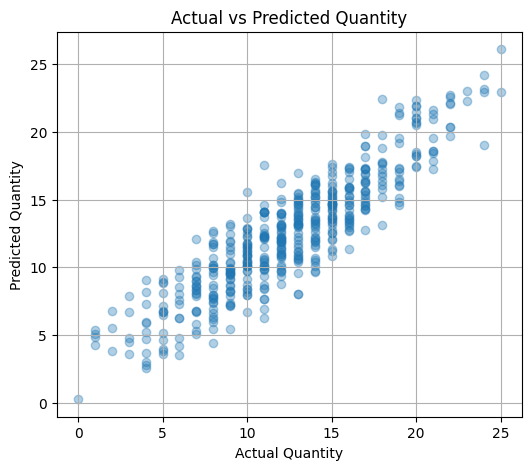

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.35)
plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Quantity")
plt.grid(True)
plt.show()

### Compute Elasticity of Demand--Price and Income

In [ ]:
# Get coefficients
beta_price = model.coef_[list(X.columns).index("price")]

# Use mean values
P_mean = df["price"].mean()
Q_mean = df["quantity_demanded"].mean()

price_elasticity = beta_price * (P_mean / Q_mean)

print("Price Elasticity:", price_elasticity)

Price Elasticity: -1.473990016201658


In [ ]:
# Compute the Income Elastcity of Demand


beta_income = model.coef_[list(X.columns).index("income")]

Y_mean = df["income"].mean()

income_elasticity = beta_income * (Y_mean / Q_mean)

print("Income Elasticity:", income_elasticity)

Income Elasticity: 0.4392966683215158


## INTERPRETATION
* Price elasticity:
    * < -1 → elastic demand
    * between -1 and 0 → inelastic
* Income elasticity:

    * 0 → normal good

    * < 0 → inferior good

    * 1 → luxury good

### Compute Individual Level Elasticity of Demand

In [ ]:
betaprice = coef_table.loc[coef_table["Variable"] == "price", "Coefficient"].values[0]
betaincome = coef_table.loc[coef_table["Variable"] == "income", "Coefficient"].values[0]



df_with_elasticity = df.copy()
df_with_elasticity["predicted_Q"] = model.predict(X)

df_with_elasticity["price_elasticity"] = betaprice * (
    df_with_elasticity["price"] / df_with_elasticity["predicted_Q"]
)

df_with_elasticity["income_elasticity"] = betaincome * (
    df_with_elasticity["income"] / df_with_elasticity["predicted_Q"]
)

df_with_elasticity[[
    "consumer_id", "price", "income", "predicted_Q",
    "price_elasticity", "income_elasticity"
]].head()

,consumer_id,price,income,predicted_Q,price_elasticity,income_elasticity
0,1,13.29,63049,11.234696,-1.781836,0.523400
1,2,10.48,53457,14.046397,-1.123829,0.354941
2,3,10.82,41887,12.735411,-1.279730,0.306749
3,4,12.06,32677,9.756181,-1.861965,0.312377
4,5,17.03,29116,1.774068,-14.459339,1.530659


In [ ]:
df_with_elasticity[["price_elasticity", "income_elasticity"]].describe()

,price_elasticity,income_elasticity
count,2500.000000,2500.000000
mean,-2.574807,0.630647
std,33.784416,6.439600
min,-1633.044861,-10.605262
25%,-2.153635,0.337514
50%,-1.459129,0.438447
75%,-1.038244,0.566370
max,206.016007,319.129900


### Group Level Summaries

In [ ]:
print("Elasticity by gender")
print(df_with_elasticity.groupby("gender")[["price_elasticity", "income_elasticity"]].mean())

print("\nElasticity by race")
print(df_with_elasticity.groupby("race")[["price_elasticity", "income_elasticity"]].mean())

print("\nElasticity by occupation")
print(df_with_elasticity.groupby("occupation")[["price_elasticity", "income_elasticity"]].mean())


print("Elasticity by age group")
print(df_with_elasticity.groupby("age_group", observed=False)[["price_elasticity", "income_elasticity"]].mean())

print("\nElasticity by income group")
print(df_with_elasticity.groupby("income_group", observed=False)[["price_elasticity", "income_elasticity"]].mean())


race_elasticity = df_with_elasticity.groupby("race")["price_elasticity"].mean().sort_values()

Elasticity by gender
        price_elasticity  income_elasticity
gender                                     
Female         -1.659915           0.457789
Male           -3.527041           0.810562

Elasticity by race
         price_elasticity  income_elasticity
race                                        
Asian           -2.267879           0.541683
Black           -2.395457           0.543252
Mexican         -1.796082           0.472768
Other           -1.838697           0.491560
White           -3.164951           0.782195

Elasticity by occupation
               price_elasticity  income_elasticity
occupation                                        
Clerical              -2.054676           0.498457
Professional          -4.407234           1.029989
Retired               -2.917301           0.632809
Self-employed         -1.720591           0.469524
Service               -2.200235           0.505540
Student               -1.368555           0.473727
Unemployed            -1.920440   

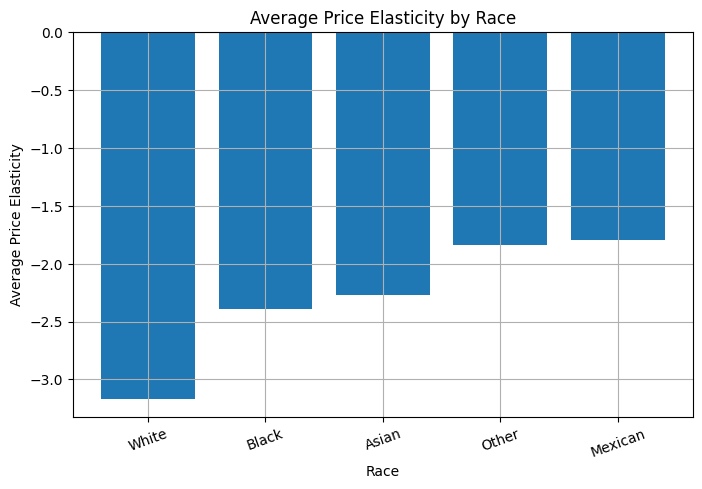

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(race_elasticity.index, race_elasticity.values)
plt.xlabel("Race")
plt.ylabel("Average Price Elasticity")
plt.title("Average Price Elasticity by Race")
plt.grid(True)
plt.xticks(rotation=20)
plt.show()

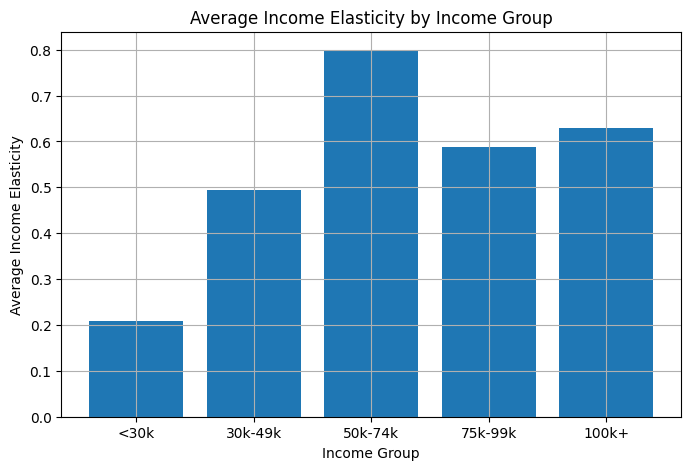

In [ ]:
income_group_elasticity = df_with_elasticity.groupby("income_group", observed=False)["income_elasticity"].mean()

plt.figure(figsize=(8, 5))
plt.bar(income_group_elasticity.index.astype(str), income_group_elasticity.values)
plt.xlabel("Income Group")
plt.ylabel("Average Income Elasticity")
plt.title("Average Income Elasticity by Income Group")
plt.grid(True)
plt.show()


##  Econometric version with statsmodels

In [ ]:
ols_model = smf.ols(
    "quantity_demanded ~ price + income + age + C(gender) + C(race) + C(occupation)",
    data=df
).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:      quantity_demanded   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     823.2
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:01:20   Log-Likelihood:                -5273.7
No. Observations:                2500   AIC:                         1.058e+04
Df Residuals:                    2485   BIC:                         1.066e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   